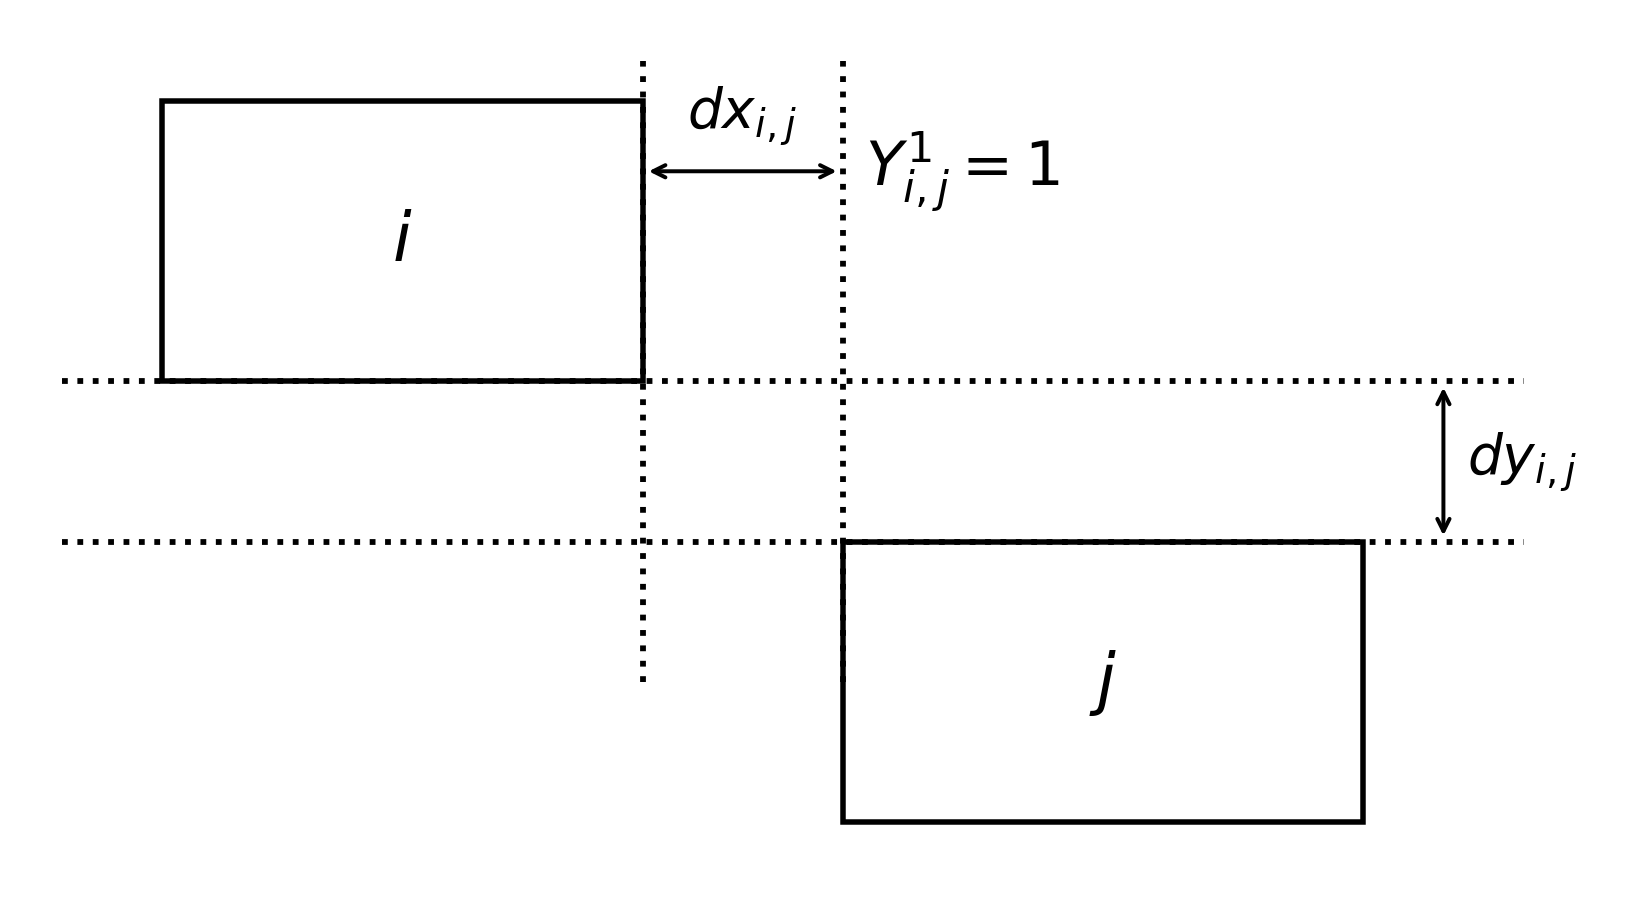

\begin{gather}
\min \; \lambda\,(l_f + w_f) + \sum_{i,j} c_{i,j}( dx_{i,j} + dy_{i,j}) \\
\text{Minimize the weighted facility size plus cost-weighted Manhattan pipe distances ($\lambda = 1$ by default)}\\
\textrm{s.t.} \;l_f \ge y_i + l_i \; \forall  i \in  N \\
\text{Facility length (the vertical $y$ axis) contains every block}\\ 
w_f \ge x_i + w_i \; \forall  i \in  N \\ 
\text{Facility width (the horizontal $x$ axis) contains every block}\\
y_1 = 0, \quad l_f = l_1 \\
\text{The pipe rack (block 1) spans the facility length: pinned at $y=0$ with the facility length fixed to the rack}\\
dx_{i,j} \ge x_i - (x_j + w_j), \quad dx_{i,j} \ge x_j - (x_i + w_i) \; \forall i,j \in N,\, j<i \\
dy_{i,j} \ge y_i - (y_j + l_j), \quad dy_{i,j} \ge y_j - (y_i + l_i) \; \forall i,j \in N,\, j<i \\
\text{Rectilinear edge gaps (0 when blocks overlap on that axis), defined globally, not inside the disjunction}\\
x_i \le UB, \; y_i \le UB \; \forall i \in  N, \quad UB = \sum_{i} \max(l_i,w_i) \\ 
\left[
\begin{array}{c}
Y_{i,j}^1\\
x_i + w_i + d_{i,j} \le x_j\\ 
\text{$i$ is left of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^2\\
x_j + w_j + d_{i,j} \le x_i\\ 
\text{$i$ is right of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^3 \\
y_i + l_i + d_{i,j} \le y_j \\ 
\text{$i$ is below $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^4 \\
y_j + l_j + d_{i,j} \le y_i \\ 
\text{$i$ is above $j$}
\end{array}
\right] \\
\text{Non-overlap: exactly one separation per pair, with the minimum clearance $d_{i,j}$ built in}\\
\\
\left[
\begin{array}{c}
Y_{i}^5 \\
l_i = l^0_i \\
w_i = w^0_i\\
\text{Default orientation}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i}^6\\
l_i = w^0_i \\
w_i = l^0_i \\
\text{Rotated orientation}
\end{array}
\right] \; \forall i \in N \setminus \{1\} \\ 
\\
l_f,w_f,l_i,w_i,x_i,y_i,dx_{i,j},dy_{i,j} \in \mathbb{R}^1_+ \\
Y_{i,j}^1,Y_{i,j}^2,Y_{i,j}^3,Y_{i,j}^4,Y_{i}^5,Y_{i}^6 \in \text{ \{ True, False \}  } \\
\forall i,j \in N, j <i
\end{gather}

Length is the vertical ($y$) axis and width the horizontal ($x$) axis. Distance is handled by the global $dx,dy$ constraints, so the disjunction decides only non-overlap, never cost. This keeps the objective independent of which spatial relation is chosen, and avoids the costly *continuous* degeneracy that coupling distance into the disjuncts would create. The pipe rack (block 1) spans the facility length and keeps a fixed orientation even when rotation is on, so the rotation disjunction applies to blocks $2 \ldots n$ only. Symmetry breaking (when `sym=1`) anchors block 1 left-of-and-below block 2: $x_1 + w_1/2 \le x_2 + w_2/2$ and $y_1 + l_1/2 \le y_2 + l_2/2$. The footprint weight $\lambda$ defaults to 1. Raise it to favor a smaller facility over cheaper piping.

In [ ]:
import random
import pandas as pd
import visuals as vs
from pyomo.environ import (ConcreteModel, NonNegativeReals, Objective, Param,
                           Set, SolverFactory, TransformationFactory, Var, value, RangeSet)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe


def create_model(n, w_0, l_0, c_0, d_0, rotate=0, sym=0, footprint_weight=1.0):

    ## Model
    m = ConcreteModel()

    ## Sets
    m.n = Set(ordered=True, initialize=RangeSet(1, n))
    def rec_pairs_filter(m, i, j):
        return i > j
    m.p = Set(initialize=m.n * m.n, dimen=2, filter=rec_pairs_filter)

    ## Parameters
    # Default-orientation width and length of each block
    m.w0 = Param(m.n, initialize=w_0)
    m.l0 = Param(m.n, initialize=l_0)
    # Pipe cost per pair (star topology: each block pipes to the rack, block 1)
    m.c = Param(m.p, initialize=c_0)
    # Minimum separation distance per pair
    m.d = Param(m.p, initialize=d_0)
    # Conservative upper bound on coordinates
    m.UB = Param(initialize=sum(max([m.l0[i], m.w0[i]]) for i in m.n))

    ## Variables
    # Lower-left corner: x is the horizontal (width) axis, y the vertical (length) axis
    m.x = Var(m.n, bounds=(0, m.UB))
    m.y = Var(m.n, bounds=(0, m.UB))
    # Rectilinear edge gaps between each pair (horizontal dx, vertical dy)
    m.dx = Var(m.p, bounds=(0, m.UB))
    m.dy = Var(m.p, bounds=(0, m.UB))
    # Block length (vertical extent) and width (horizontal extent)
    m.l = Var(m.n, bounds=(0, m.UB))
    m.w = Var(m.n, bounds=(0, m.UB))
    # Facility length (vertical) and width (horizontal)
    m.l_f = Var(within=NonNegativeReals)
    m.w_f = Var(within=NonNegativeReals)

    ## Constraints
    # Facility bounding box: length is the vertical (y) axis, width the horizontal (x)
    @m.Constraint(m.n)
    def facility_length(m, i):
        return m.l_f >= m.y[i] + m.l[i]
    @m.Constraint(m.n)
    def facility_width(m, i):
        return m.w_f >= m.x[i] + m.w[i]

    # Pipe rack (block 1) spans the facility length: pinned at y=0 with the
    # facility length fixed to the rack. Only the facility width is minimized.
    @m.Constraint()
    def rack_at_origin(m):
        return m.y[1] == 0
    @m.Constraint()
    def facility_len_eq_rack(m):
        return m.l_f == m.l[1]

    # Rectilinear edge gaps, defined globally so the objective never depends on
    # which spatial relation the disjunction picks. Each is minimized, so it
    # settles to the true clearance (0 if the blocks overlap on that axis).
    @m.Constraint(m.p)
    def dx_lb_a(m, i, j):
        return m.dx[i,j] >= m.x[i] - (m.x[j] + m.w[j])
    @m.Constraint(m.p)
    def dx_lb_b(m, i, j):
        return m.dx[i,j] >= m.x[j] - (m.x[i] + m.w[i])
    @m.Constraint(m.p)
    def dy_lb_a(m, i, j):
        return m.dy[i,j] >= m.y[i] - (m.y[j] + m.l[j])
    @m.Constraint(m.p)
    def dy_lb_b(m, i, j):
        return m.dy[i,j] >= m.y[j] - (m.y[i] + m.l[i])

    # Symmetry breaking: anchor block 1 left-of-and-below block 2's center.
    if sym == 1:
        @m.Constraint()
        def sym_1(m):
            return m.x[1] + m.w[1]/2 <= m.x[2] + m.w[2]/2
        @m.Constraint()
        def sym_2(m):
            return m.y[1] + m.l[1]/2 <= m.y[2] + m.l[2]/2

    ## Objective: weighted facility size + cost-weighted Manhattan piping.
    ## footprint_weight (default 1) trades facility size against piping cost.
    m.obj = Objective(expr=footprint_weight * (m.l_f + m.w_f)
                      + sum(m.c[i,j] * (m.dx[i,j] + m.dy[i,j]) for i,j in m.p))

    # Non-overlap: exactly one of four separations per pair, each a single
    # inequality with the minimum clearance d baked in.
    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        return [
            [m.x[i] + m.w[i] + m.d[i,j] <= m.x[j]],   # i left of j
            [m.x[j] + m.w[j] + m.d[i,j] <= m.x[i]],   # i right of j
            [m.y[i] + m.l[i] + m.d[i,j] <= m.y[j]],   # i below j
            [m.y[j] + m.l[j] + m.d[i,j] <= m.y[i]],   # i above j
            ]

    # Rotation (optional): a 2-way orientation disjunction per block, except the
    # rack (block 1), which keeps its orientation even when rotation is on.
    if rotate:
        rot_blocks = [i for i in m.n if i != 1]
        @m.Disjunction(rot_blocks)
        def rotation(m, i):
            return [
                [m.l[i] == m.l0[i], m.w[i] == m.w0[i]],   # default orientation
                [m.l[i] == m.w0[i], m.w[i] == m.l0[i]],   # 90 degrees rotated
                ]
        @m.Constraint()
        def fix_rack_l(m):
            return m.l[1] == m.l0[1]
        @m.Constraint()
        def fix_rack_w(m):
            return m.w[1] == m.w0[1]
    else:
        @m.Constraint(m.n)
        def fix_l(m, i):
            return m.l[i] == m.l0[i]
        @m.Constraint(m.n)
        def fix_w(m, i):
            return m.w[i] == m.w0[i]
    return m

In [ ]:
# Default instance: the pipe rack (block 1) plus 14 objects. The rack is the
# longest block (length 9, width 1) and spans the facility.
num = 15

# Length (vertical extent) and width (horizontal extent) of each block
l_0 = {1: 9, 2: 1, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 3,
       9: 3, 10: 1, 11: 1, 12: 3, 13: 3, 14: 3, 15: 1}
w_0 = {1: 1, 2: 3, 3: 1, 4: 2, 5: 1, 6: 1, 7: 3, 8: 2,
       9: 1, 10: 2, 11: 1, 12: 1, 13: 1, 14: 1, 15: 2}

# Star topology: every block pipes to the rack (block 1) only, so cost(i, 1) > 0
# for i >= 2 and every other pair is 0.
rack_cost = {2: 1, 3: 2, 4: 3, 5: 1, 6: 2, 7: 1, 8: 2,
             9: 3, 10: 1, 11: 3, 12: 2, 13: 2, 14: 3, 15: 2}
c_0 = {(i, j): (rack_cost[i] if j == 1 else 0)
       for i in range(1, num + 1) for j in range(1, num + 1) if i > j}

# Minimum separation distance for every pair
d_0 = {(i, j): 1 for i in range(1, num + 1) for j in range(1, num + 1) if i > j}

In [ ]:
m = create_model(num, w_0, l_0, c_0, d_0, rotate=0, sym=1)
TransformationFactory('gdp.bigm').apply_to(m)

# HiGHS is the open-source MILP solver (pip install highspy). The native appsi
# interface respects the time limit and still loads a timed-out incumbent. On
# this instance HiGHS may hit the limit before proving optimality.
from pyomo.contrib.appsi.solvers import Highs

opt = Highs()
opt.config.time_limit = 60
opt.config.load_solution = False
opt.config.stream_solver = True
res = opt.solve(m)
if res.best_feasible_objective is not None:
    res.solution_loader.load_vars()

print("termination:", res.termination_condition)
print("objective:  ", res.best_feasible_objective)

In [ ]:
vs.plot_rect_layout(m, title="Facility Layout")
vs.rect_table(m,decimals = 0)

In [ ]:
print(c_0)